## Load Data

In [1]:
import pandas as pd
import numpy as np
import os
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans
server = r"SIX\SQLEXPRESS"
database = "OlistDB"

connection_string = (
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

engine = create_engine(connection_string)

# Load các bảng chính (điều chỉnh path theo thư mục của bạn)
dataset_dir = r'C:\Users\nghah\OneDrive\Documents\dataset\dataset'

# Đọc các file CSV bằng cách nối thư mục gốc với tên file
orders = pd.read_csv(os.path.join(dataset_dir, 'olist_orders_dataset.csv'))
customers = pd.read_csv(os.path.join(dataset_dir, 'olist_customers_dataset.csv'))
order_items = pd.read_csv(os.path.join(dataset_dir, 'olist_order_items_dataset.csv'))
payments = pd.read_csv(os.path.join(dataset_dir, 'olist_order_payments_dataset.csv'))
reviews = pd.read_csv(os.path.join(dataset_dir, 'olist_order_reviews_dataset.csv'))
products = pd.read_csv(os.path.join(dataset_dir, 'olist_products_dataset.csv'))
sellers = pd.read_csv(os.path.join(dataset_dir, 'olist_sellers_dataset.csv'))
category = pd.read_csv(os.path.join(dataset_dir, 'product_category_name_translation.csv'))

# Convert timestamp columns sang datetime ngay từ đầu
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

## Overview (row, columns, dtypes)

In [2]:
tables = {
    'orders': orders, 'customers': customers, 'order_items': order_items,
    'payments': payments, 'reviews': reviews, 'products': products, 'sellers': sellers
}

for name, df in tables.items():
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(df.dtypes.value_counts().to_dict())
    print("-" * 40)

orders: 99,441 rows x 8 columns
{dtype('<M8[ns]'): 5, dtype('O'): 3}
----------------------------------------
customers: 99,441 rows x 5 columns
{dtype('O'): 4, dtype('int64'): 1}
----------------------------------------
order_items: 112,650 rows x 7 columns
{dtype('O'): 4, dtype('float64'): 2, dtype('int64'): 1}
----------------------------------------
payments: 103,886 rows x 5 columns
{dtype('O'): 2, dtype('int64'): 2, dtype('float64'): 1}
----------------------------------------
reviews: 99,224 rows x 7 columns
{dtype('O'): 6, dtype('int64'): 1}
----------------------------------------
products: 32,951 rows x 9 columns
{dtype('float64'): 7, dtype('O'): 2}
----------------------------------------
sellers: 3,095 rows x 4 columns
{dtype('O'): 3, dtype('int64'): 1}
----------------------------------------


## Statistic table

In [3]:
numeric_summary = pd.DataFrame({
    'price': order_items['price'],
})['price'].describe()

# Cách nhanh cho nhiều biến cùng lúc
num_vars = {
    'price (BRL)': order_items['price'],
    'freight_value (BRL)': order_items['freight_value'],
    'payment_value (BRL)': payments['payment_value'],
    'payment_installments': payments['payment_installments'],
    'review_score (1-5)': reviews['review_score']
}

summary_rows = []
for name, series in num_vars.items():
    summary_rows.append({
        'Variable': name,
        'Mean': round(series.mean(), 2),
        'Median': round(series.median(), 2),
        'Std Dev': round(series.std(), 2),
        'Min': series.min(),
        'Max': series.max(),
        'Skewness': round(series.skew(), 2)   # <-- bổ sung so với report gốc
    })

numeric_summary_table = pd.DataFrame(summary_rows)
print(numeric_summary_table)

               Variable    Mean  Median  Std Dev   Min       Max  Skewness
0           price (BRL)  120.65   74.99   183.63  0.85   6735.00      7.92
1   freight_value (BRL)   19.99   16.26    15.81  0.00    409.68      5.64
2   payment_value (BRL)  154.10  100.00   217.49  0.00  13664.08      9.25
3  payment_installments    2.85    1.00     2.69  0.00     24.00      1.66
4    review_score (1-5)    4.09    5.00     1.35  1.00      5.00     -1.36


## statistic classification table

In [4]:
cat_vars = {
    'order_status': orders['order_status'],
    'payment_type': payments['payment_type'],
    'customer_state': customers['customer_state'],
    'seller_state': sellers['seller_state'],
    'review_score': reviews['review_score']
}

cat_summary_rows = []
for name, series in cat_vars.items():
    vc = series.value_counts()
    mode_val = vc.index[0]
    freq = vc.iloc[0]
    pct = round(freq / len(series) * 100, 1)
    cat_summary_rows.append({
        'Variable': name,
        'Unique Count': series.nunique(),
        'Mode': mode_val,
        'Frequency': f"{freq:,} ({pct}%)"
    })

cat_summary_table = pd.DataFrame(cat_summary_rows)
print(cat_summary_table)

         Variable  Unique Count         Mode       Frequency
0    order_status             8    delivered  96,478 (97.0%)
1    payment_type             5  credit_card  76,795 (73.9%)
2  customer_state            27           SP  41,746 (42.0%)
3    seller_state            23           SP   1,849 (59.7%)
4    review_score             5            5  57,328 (57.8%)


## Check duplication

In [5]:
print("Duplicate order_id:", orders['order_id'].duplicated().sum())
print("Duplicate customer_unique_id rows:", customers.duplicated().sum())
print("Fully duplicated rows in order_items:", order_items.duplicated().sum())

Duplicate order_id: 0
Duplicate customer_unique_id rows: 0
Fully duplicated rows in order_items: 0


## Data Volume follow by year

In [6]:
orders['order_year'] = orders['order_purchase_timestamp'].dt.year
yearly_volume = orders['order_year'].value_counts().sort_index()
yearly_pct = (yearly_volume / yearly_volume.sum() * 100).round(1)

volume_by_year = pd.DataFrame({
    'Order Count': yearly_volume,
    'Percentage': yearly_pct
})
print(volume_by_year)

            Order Count  Percentage
order_year                         
2016                329         0.3
2017              45101        45.4
2018              54011        54.3


## Check outlier in EDA

In [7]:
# Price outliers theo IQR
Q1, Q3 = order_items['price'].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
print(f"Price upper bound (IQR): {upper_bound:.2f} BRL")
print(f"Số orders vượt ngưỡng: {(order_items['price'] > upper_bound).sum()}")
print(f"Max price: {order_items['price'].max()}")  # để đối chiếu với 6,735 BRL trong báo cáo

# Payment installments = 0 (bất thường nghiệp vụ)
zero_installments = (payments['payment_installments'] == 0).sum()
print(f"Payments với installments = 0: {zero_installments}")

Price upper bound (IQR): 277.40 BRL
Số orders vượt ngưỡng: 8427
Max price: 6735.0
Payments với installments = 0: 2


## Missing Value Overview

In [8]:
def missing_report(df, table_name):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    report = pd.DataFrame({'NULL Count': missing, 'NULL %': missing_pct})
    report = report[report['NULL Count'] > 0]
    report['Table'] = table_name
    return report

all_missing = pd.concat([
    missing_report(orders, 'orders'),
    missing_report(products, 'products'),
    missing_report(reviews, 'reviews')
])
print(all_missing)

                               NULL Count  NULL %     Table
order_approved_at                     160    0.16    orders
order_delivered_carrier_date         1783    1.79    orders
order_delivered_customer_date        2965    2.98    orders
product_category_name                 610    1.85  products
product_name_lenght                   610    1.85  products
product_description_lenght            610    1.85  products
product_photos_qty                    610    1.85  products
product_weight_g                        2    0.01  products
product_length_cm                       2    0.01  products
product_height_cm                       2    0.01  products
product_width_cm                        2    0.01  products
review_comment_title                87656   88.34   reviews
review_comment_message              58247   58.70   reviews


### Visisor quantity by code

In [9]:
# Review score bimodal check
review_dist = reviews['review_score'].value_counts(normalize=True).sort_index() * 100
print(review_dist.round(1))

# Late delivery rate
delivered = orders.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date'])
late_rate = (delivered['order_delivered_customer_date'] > delivered['order_estimated_delivery_date']).mean() * 100
print(f"Late delivery rate: {late_rate:.1f}%")

review_score
1    11.5
2     3.2
3     8.2
4    19.3
5    57.8
Name: proportion, dtype: float64
Late delivery rate: 8.1%


## CLEAN DATA

### Điền median cho kích thước sản phẩm

In [10]:
# Kiểm chứng TRƯỚC khi điền
print("NULL trước khi xử lý:")
print(products[['product_weight_g','product_length_cm',
                 'product_height_cm','product_width_cm']].isnull().sum())

for col in ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']:
    median_val = products[col].median()
    products[col] = products[col].fillna(median_val)
    print(f"{col}: điền {products[col].isnull().sum()} NULL còn lại bằng median = {median_val}")

# Kiểm chứng SAU khi điền
print("\nNULL sau khi xử lý:")
print(products[['product_weight_g','product_length_cm',
                 'product_height_cm','product_width_cm']].isnull().sum())

NULL trước khi xử lý:
product_weight_g     2
product_length_cm    2
product_height_cm    2
product_width_cm     2
dtype: int64
product_weight_g: điền 0 NULL còn lại bằng median = 700.0
product_length_cm: điền 0 NULL còn lại bằng median = 25.0
product_height_cm: điền 0 NULL còn lại bằng median = 13.0
product_width_cm: điền 0 NULL còn lại bằng median = 20.0

NULL sau khi xử lý:
product_weight_g     0
product_length_cm    0
product_height_cm    0
product_width_cm     0
dtype: int64


## Cap Price

In [11]:
# BEFORE: thống kê mô tả trước khi xử lý
print("--- TRƯỚC KHI XỬ LÝ OUTLIER ---")
print(order_items['price'].describe())

Q1 = order_items['price'].quantile(0.25)
Q3 = order_items['price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
print(f"\nQ1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, upper_bound={upper_bound:.2f}")

n_outliers = (order_items['price'] > upper_bound).sum()
n_extreme = (order_items['price'] > 5000).sum()
print(f"Số dòng vượt ngưỡng IQR: {n_outliers}")
print(f"Số dòng cực đoan (>5000 BRL): {n_extreme}")

# XỬ LÝ
order_items['price_capped'] = order_items['price'].clip(upper=upper_bound)
order_items = order_items[order_items['price'] <= 5000]

# AFTER
print("\n--- SAU KHI XỬ LÝ OUTLIER ---")
print(order_items['price_capped'].describe())

--- TRƯỚC KHI XỬ LÝ OUTLIER ---
count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

Q1=39.90, Q3=134.90, IQR=95.00, upper_bound=277.40
Số dòng vượt ngưỡng IQR: 8427
Số dòng cực đoan (>5000 BRL): 3

--- SAU KHI XỬ LÝ OUTLIER ---
count    112647.000000
mean         98.439457
std          75.918638
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max         277.400000
Name: price_capped, dtype: float64


## Preparing

### Classification payment

In [12]:
payment_encoded = pd.get_dummies(payments['payment_type'], prefix='payment')

print("--- KIỂM CHỨNG ONE-HOT ---")
print(payment_encoded.sum())   # đếm số lượng mỗi loại
print("\nTỷ lệ %:")
print((payment_encoded.sum() / len(payment_encoded) * 100).round(2))

--- KIỂM CHỨNG ONE-HOT ---
payment_boleto         19784
payment_credit_card    76795
payment_debit_card      1529
payment_not_defined        3
payment_voucher         5775
dtype: int64

Tỷ lệ %:
payment_boleto         19.04
payment_credit_card    73.92
payment_debit_card      1.47
payment_not_defined     0.00
payment_voucher         5.56
dtype: float64


### label customers state

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
customers['customer_state_encoded'] = le.fit_transform(customers['customer_state'])

print("--- KIỂM CHỨNG LABEL ENCODING ---")
print(f"Số lượng nhãn (state) duy nhất: {len(le.classes_)}")
print(f"Khoảng giá trị mã hóa: {customers['customer_state_encoded'].min()} - {customers['customer_state_encoded'].max()}")
print("\nBảng ánh xạ mẫu:")
for state, code in list(zip(le.classes_, range(len(le.classes_))))[:5]:
    print(f"  {state} -> {code}")

--- KIỂM CHỨNG LABEL ENCODING ---
Số lượng nhãn (state) duy nhất: 27
Khoảng giá trị mã hóa: 0 - 26

Bảng ánh xạ mẫu:
  AC -> 0
  AL -> 1
  AM -> 2
  AP -> 3
  BA -> 4


In [14]:
order_value_df = (
    order_items
    .groupby('order_id', as_index=False)
    .agg(order_total=('price', 'sum'))
)

order_value_df.head()

,order_id,order_total
0,00010242fe8c5a6d1ba2dd792cb16214,58.90
1,00018f77f2f0320c557190d7a144bdd3,239.90
2,000229ec398224ef6ca0657da4fc703e,199.00
3,00024acbcdf0a6daa1e931b038114c75,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90


In [15]:
import pandas as pd

# ============================================================
# BƯỚC 1: Merge delivered (orders đã lọc status = delivered) 
# với customers để lấy customer_unique_id
# ============================================================
orders_customers_df = delivered.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)

# ============================================================
# BƯỚC 2: Merge với order_value_df (đã có sẵn order_total)
# ============================================================
orders_full_df = orders_customers_df.merge(
    order_value_df[['order_id', 'order_total']],   # đổi tên cột nếu khác
    on='order_id',
    how='left'
)

# Đảm bảo timestamp đúng kiểu datetime
orders_full_df['order_purchase_timestamp'] = pd.to_datetime(
    orders_full_df['order_purchase_timestamp']
)

# ============================================================
# BƯỚC 3: Snapshot date để tính Recency
# ============================================================
snapshot_date = orders_full_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# ============================================================
# BƯỚC 4: Tính RFM theo customer_unique_id
# ============================================================
rfm_df = (
    orders_full_df
    .groupby('customer_unique_id')
    .agg(
        recency_days=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
        purchase_frequency=('order_id', 'nunique'),
        monetary_total=('order_total', 'sum')
    )
    .reset_index()
)

rfm_df = rfm_df.dropna(subset=['monetary_total'])

print("--- KIỂM CHỨNG RFM ---")
print(f"Số khách hàng duy nhất (customer_unique_id): {rfm_df['customer_unique_id'].nunique()}")
print(rfm_df[['recency_days','purchase_frequency','monetary_total']].describe())

--- KIỂM CHỨNG RFM ---
Số khách hàng duy nhất (customer_unique_id): 93356
       recency_days  purchase_frequency  monetary_total
count  93356.000000         93356.00000    93356.000000
mean     237.973842             1.03342      141.404217
std      152.621155             0.20910      212.513508
min        1.000000             1.00000        0.000000
25%      114.000000             1.00000       47.650000
50%      219.000000             1.00000       89.700000
75%      346.000000             1.00000      154.532500
max      714.000000            15.00000    13440.000000


## Prepare for python

In [16]:
# --- Code gốc đã có trong báo cáo ---
items_clean = pd.read_sql("SELECT * FROM dbo.Cleaned_Orders_Items", engine)

df = (items_clean
     .merge(products[['product_id', 'product_category_name']], on='product_id')
     .merge(category, on='product_category_name', how='left'))

# --- Kiểm tra số dòng trước/sau merge (thêm mới) ---
print("Số dòng items_clean gốc:", items_clean.shape[0])
print("Số dòng sau merge với products:", df.shape[0])

# Kiểm tra số lượng NULL trước khi fillna
print("Số sản phẩm không có category (trước fillna):",
      df['product_category_name_english'].isna().sum())

df['product_category_name_english'] = df['product_category_name_english'].fillna('unknown')

# Kiểm tra kết quả sau khi fill
print("Top 10 category phổ biến nhất sau khi merge:")
print(df['product_category_name_english'].value_counts().head(10))

C:\ProgramData\anaconda3\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1125.2'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


Số dòng items_clean gốc: 112650
Số dòng sau merge với products: 112650
Số sản phẩm không có category (trước fillna): 1627
Top 10 category phổ biến nhất sau khi merge:
product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: count, dtype: int64


In [17]:
# --- Code gốc đã có trong báo cáo ---
orders['hour'] = orders['order_purchase_timestamp'].dt.hour
orders['dayofweek'] = orders['order_purchase_timestamp'].dt.day_name()
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M').astype(str)

heatmap_data = (orders.groupby(['dayofweek', 'hour']).size().reset_index(name='count'))
pivot = heatmap_data.pivot(index='dayofweek', columns='hour', values='count')

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = pivot.reindex(day_order)

# --- Kiểm tra kết quả (thêm mới) ---
print("Kích thước bảng pivot (7 ngày x 24 giờ):", pivot.shape)
print("\n5 dòng đầu bảng pivot:")
print(pivot.head())

# Tìm khung giờ cao điểm nhất
peak_day, peak_hour = pivot.stack().idxmax()
peak_value = pivot.stack().max()
print(f"\nKhung giờ cao điểm nhất: {peak_day} lúc {peak_hour}h "
      f"với {peak_value} đơn hàng")

Kích thước bảng pivot (7 ngày x 24 giờ): (7, 24)

5 dòng đầu bảng pivot:
hour        0    1   2   3   4   5   6    7    8    9   ...    14    15    16  \
dayofweek                                               ...                     
Monday     328  134  66  36  21  22  69  160  479  783  ...  1096  1079  1094   
Tuesday    306  158  80  28  29  24  71  223  522  864  ...  1124  1047  1081   
Wednesday  397  179  81  33  33  27  93  211  517  829  ...  1050   983  1040   
Thursday   355  167  75  39  31  28  85  220  502  758  ...   977   928  1077   
Friday     426  216  72  49  40  36  97  206  493  768  ...   961   979   974   

hour        17   18   19    20    21   22   23  
dayofweek                                       
Monday     992  928  945  1027  1118  991  717  
Tuesday    967  877  924   988  1027  965  692  
Wednesday  967  852  848   904   963  878  615  
Thursday   909  784  826   839   840  857  551  
Friday     817  723  784   738   726  702  512  

[5 rows x 24 co

In [18]:
rfm = rfm_df.copy()

rfm['R'] = pd.qcut(rfm['recency_days'], q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['purchase_frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary_total'], q=5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = rfm['R'] * 100 + rfm['F'] * 10 + rfm['M']

print(rfm.head(10))

                 customer_unique_id  recency_days  purchase_frequency  \
0  0000366f3b9a7992bf8c76cfdf3221e2           112                   1   
1  0000b849f77a49e4a4ce2b2a4ca5be3f           115                   1   
2  0000f46a3911fa3c0805444483337064           537                   1   
3  0000f6ccb0745a6a4b88665a16c9f078           321                   1   
4  0004aac84e0df4da2b147fca70cf8255           288                   1   
5  0004bd2a26a76fe21f786e4fbd80607f           146                   1   
6  00050ab1314c0e55a6ca13cf7181fecf           132                   1   
7  00053a61a98854899e70ed204dd4bafe           183                   1   
8  0005e1862207bf6ccc02e4228effd9a0           543                   1   
9  0005ef4cd20d2893f0d9fbd94d3c0d97           170                   1   

   monetary_total  R  F  M  RFM_Score  
0          129.90  4  1  4        414  
1           18.90  4  1  1        411  
2           69.00  1  1  2        112  
3           25.99  2  1  1        21

### Python Data Analysis 

In [19]:
items_clean = pd.read_sql("SELECT * FROM dbo.Cleaned_Orders_Items", engine)
df = (items_clean
     .merge(products[['product_id', 'product_category_name']], on='product_id')
     .merge(category, on='product_category_name', how='left'))
df['product_category_name_english'] = df['product_category_name_english'].fillna('unknown')


In [20]:
orders['hour'] = orders['order_purchase_timestamp'].dt.hour
orders['dayofweek'] = orders['order_purchase_timestamp'].dt.day_name()
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M').astype(str)
heatmap_data = (orders.groupby(['dayofweek', 'hour']).size().reset_index(name='count'))
pivot = heatmap_data.pivot(index='dayofweek', columns='hour', values='count')
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = pivot.reindex(day_order)


In [21]:
rfm = rfm_df.copy()
rfm['R'] = pd.qcut(rfm['recency_days'], q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['purchase_frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary_total'], q=5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Score'] = rfm['R'] * 100 + rfm['F'] * 10 + rfm['M']


## Visual by python

### Revenue

In [22]:

# --- Option A: Lấy dữ liệu trực tiếp từ SQL (khớp với Query 1 trong báo cáo) ---
query = """
SELECT
    YEAR(o.order_purchase_timestamp) AS year,
    MONTH(o.order_purchase_timestamp) AS month,
    SUM(i.price) AS product_revenue,
    SUM(i.freight_value) AS freight_revenue,
    SUM(i.price + i.freight_value) AS total_revenue,
    COUNT(DISTINCT o.order_id) AS orders_count
FROM Cleaned_Orders o
JOIN Cleaned_Orders_Items i ON o.order_id = i.order_id
GROUP BY YEAR(o.order_purchase_timestamp), MONTH(o.order_purchase_timestamp)
ORDER BY 1, 2;
"""
revenue_df = pd.read_sql(query, engine)

# --- Option B: Nếu bạn đã có DataFrame orders/items trong Python, tự group bằng pandas ---
# orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
# revenue_df = (orders.merge(items, on='order_id')
#               .groupby('order_month')
#               .agg(total_revenue=('price', lambda x: (x + items.loc[x.index,'freight_value']).sum()))
#               .reset_index())

In [23]:
# Tạo cột date từ year + month để dùng làm trục x dạng thời gian thực
revenue_df['date'] = pd.to_datetime(
    revenue_df['year'].astype(str) + '-' + revenue_df['month'].astype(str) + '-01'
)
revenue_df = revenue_df.sort_values('date').reset_index(drop=True)

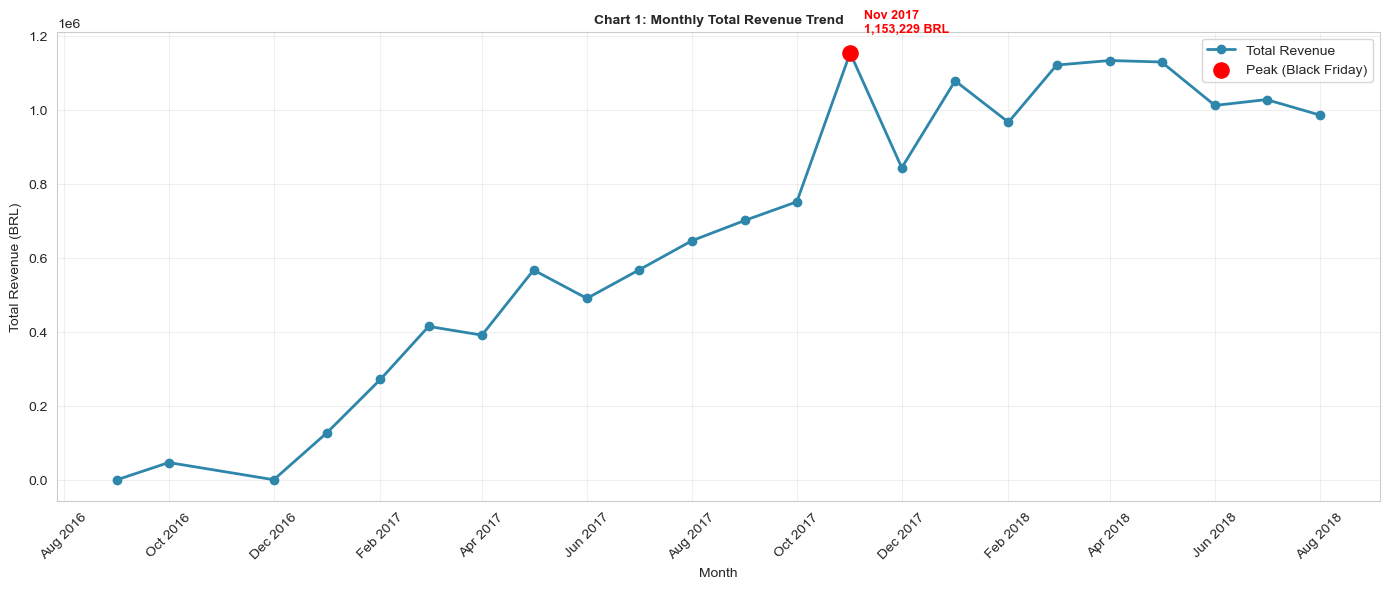

In [24]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(revenue_df['date'], revenue_df['total_revenue'],
        marker='o', linewidth=2, color='#2E86AB', label='Total Revenue')

# Đánh dấu điểm peak (doanh thu cao nhất) - vd. tháng 11/2017 Black Friday
peak_idx = revenue_df['total_revenue'].idxmax()
peak_row = revenue_df.loc[peak_idx]
ax.scatter(peak_row['date'], peak_row['total_revenue'],
           color='red', s=120, zorder=5, label='Peak (Black Friday)')
ax.annotate(f"{peak_row['date'].strftime('%b %Y')}\n{peak_row['total_revenue']:,.0f} BRL",
            xy=(peak_row['date'], peak_row['total_revenue']),
            xytext=(10, 15), textcoords='offset points',
            fontsize=9, color='red', fontweight='bold')

# Định dạng trục x theo tháng/năm
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# Labels & title theo chuẩn compliance trong báo cáo
ax.set_title('Chart 1: Monthly Total Revenue Trend', fontsize=10, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (BRL)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('chart11_monthly_revenue_trend.png', dpi=150)
plt.show()

### Top 10 category theo revenue and volume

In [25]:
query = """
SELECT
    t.product_category_name_english AS category,
    SUM(i.price + i.freight_value) AS total_revenue,
    COUNT(DISTINCT i.order_id) AS order_count,
    COUNT(*) AS item_count
FROM Cleaned_Orders_Items i
JOIN products p ON i.product_id = p.product_id
LEFT JOIN product_category_name_translation t
    ON p.product_category_name = t.product_category_name
GROUP BY t.product_category_name_english;
"""
cat_df = pd.read_sql(query, engine)
cat_df['category'] = cat_df['category'].fillna('unknown')


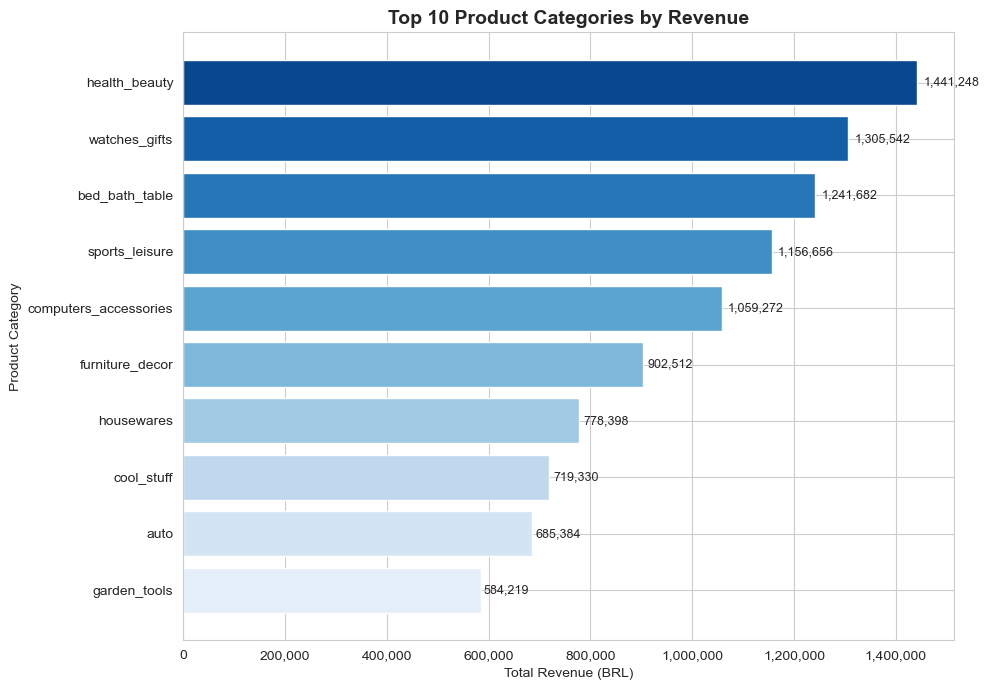

In [26]:
top10_revenue = cat_df.sort_values('total_revenue', ascending=False).head(10)
top10_revenue = top10_revenue.sort_values('total_revenue')  # để bar dài nhất nằm trên cùng

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette("Blues", len(top10_revenue))  # single-hue ramp theo rank

bars = ax.barh(top10_revenue['category'], top10_revenue['total_revenue'], color=colors)

# Gắn nhãn giá trị cuối mỗi bar
for bar, value in zip(bars, top10_revenue['total_revenue']):
    ax.text(bar.get_width() + value*0.01, bar.get_y() + bar.get_height()/2,
            f"{value:,.0f}", va='center', fontsize=9)

ax.set_title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (BRL)')
ax.set_ylabel('Product Category')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('top10_category_revenue.png', dpi=150)
plt.show()

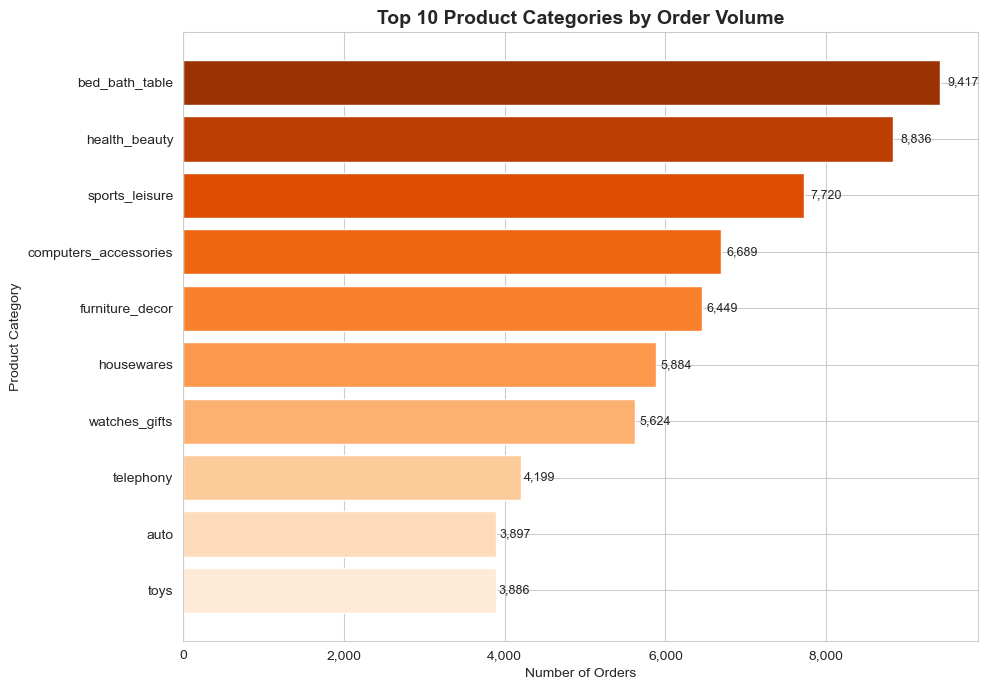

In [27]:
top10_volume = cat_df.sort_values('order_count', ascending=False).head(10)
top10_volume = top10_volume.sort_values('order_count')

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette("Oranges", len(top10_volume))

bars = ax.barh(top10_volume['category'], top10_volume['order_count'], color=colors)

for bar, value in zip(bars, top10_volume['order_count']):
    ax.text(bar.get_width() + value*0.01, bar.get_y() + bar.get_height()/2,
            f"{value:,.0f}", va='center', fontsize=9)

ax.set_title('Top 10 Product Categories by Order Volume', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Product Category')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('top10_category_volume.png', dpi=150)
plt.show()

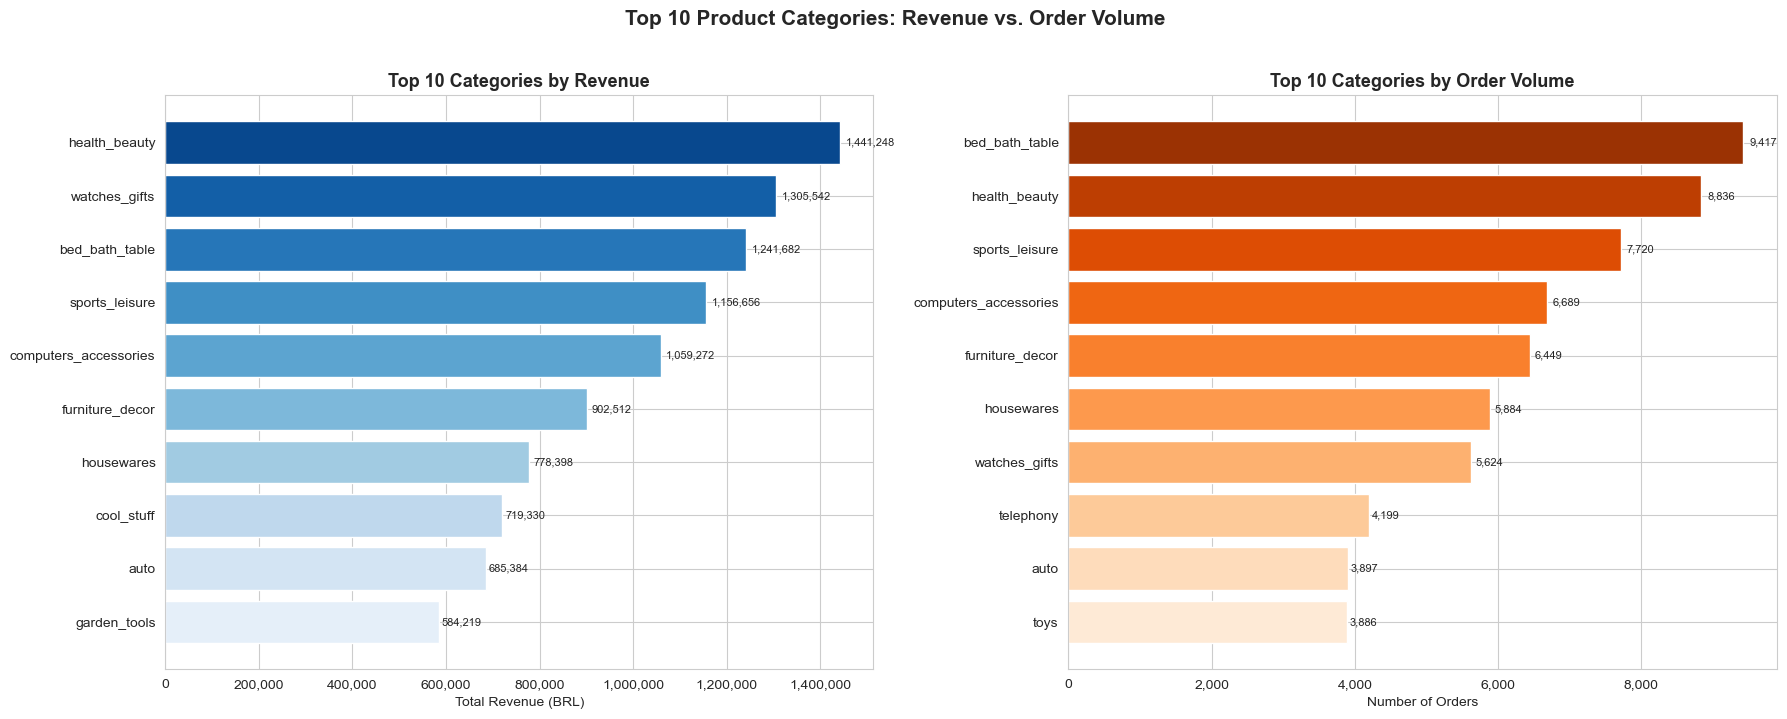

In [28]:
sns.set_style("whitegrid")

# --- Dữ liệu cat_df đã có từ bước trước (category, total_revenue, order_count) ---

top10_revenue = cat_df.sort_values('total_revenue', ascending=False).head(10).sort_values('total_revenue')
top10_volume  = cat_df.sort_values('order_count', ascending=False).head(10).sort_values('order_count')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ---- Subplot 1: Revenue ----
colors_rev = sns.color_palette("Blues", len(top10_revenue))
bars1 = axes[0].barh(top10_revenue['category'], top10_revenue['total_revenue'], color=colors_rev)
for bar, value in zip(bars1, top10_revenue['total_revenue']):
    axes[0].text(bar.get_width() + value*0.01, bar.get_y() + bar.get_height()/2,
                 f"{value:,.0f}", va='center', fontsize=8)
axes[0].set_title('Top 10 Categories by Revenue', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Revenue (BRL)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ---- Subplot 2: Volume ----
colors_vol = sns.color_palette("Oranges", len(top10_volume))
bars2 = axes[1].barh(top10_volume['category'], top10_volume['order_count'], color=colors_vol)
for bar, value in zip(bars2, top10_volume['order_count']):
    axes[1].text(bar.get_width() + value*0.01, bar.get_y() + bar.get_height()/2,
                 f"{value:,.0f}", va='center', fontsize=8)
axes[1].set_title('Top 10 Categories by Order Volume', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Orders')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle('Top 10 Product Categories: Revenue vs. Order Volume', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('top10_category_combined.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
cat_df['rank_revenue'] = cat_df['total_revenue'].rank(ascending=False)
cat_df['rank_volume'] = cat_df['order_count'].rank(ascending=False)
cat_df['rank_gap'] = cat_df['rank_volume'] - cat_df['rank_revenue']

# Category có volume cao nhưng revenue thấp (traffic driver, giá trị đơn thấp)
traffic_driver = cat_df[cat_df['rank_gap'] < -5].sort_values('rank_gap')

# Category có revenue cao nhưng volume thấp (giá trị đơn cao, ít đơn)
revenue_driver = cat_df[cat_df['rank_gap'] > 5].sort_values('rank_gap', ascending=False)

print("Traffic driver categories (volume >> revenue rank):")
print(traffic_driver[['category', 'rank_revenue', 'rank_volume']].head())

print("\nRevenue driver categories (revenue >> volume rank):")
print(revenue_driver[['category', 'rank_revenue', 'rank_volume']].head())

Traffic driver categories (volume >> revenue rank):
                  category  rank_revenue  rank_volume
11         books_technical          50.0         35.0
25                  drinks          47.0         33.0
37                    food          42.0         29.0
9   books_general_interest          37.0         27.0
38              food_drink          51.0         42.0

Revenue driver categories (revenue >> volume rank):
                                 category  rank_revenue  rank_volume
15                              computers          18.0         47.0
65  small_appliances_home_oven_and_coffee          38.0         56.0
1              agro_industry_and_commerce          31.0         46.0
46                      home_appliances_2          27.0         41.0
35                        fixed_telephony          33.0         43.0


### Top 10 bang co so luong don nhieu nhat

In [30]:
sns.set_style("whitegrid")

# --- Option A: Lấy từ SQL ---
query = """
SELECT
    c.customer_city AS city,
    c.customer_state AS state,
    COUNT(DISTINCT o.order_id) AS order_count
FROM Cleaned_Orders o
JOIN Cleaned_Customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_city, c.customer_state;
"""
city_df = pd.read_sql(query, engine)

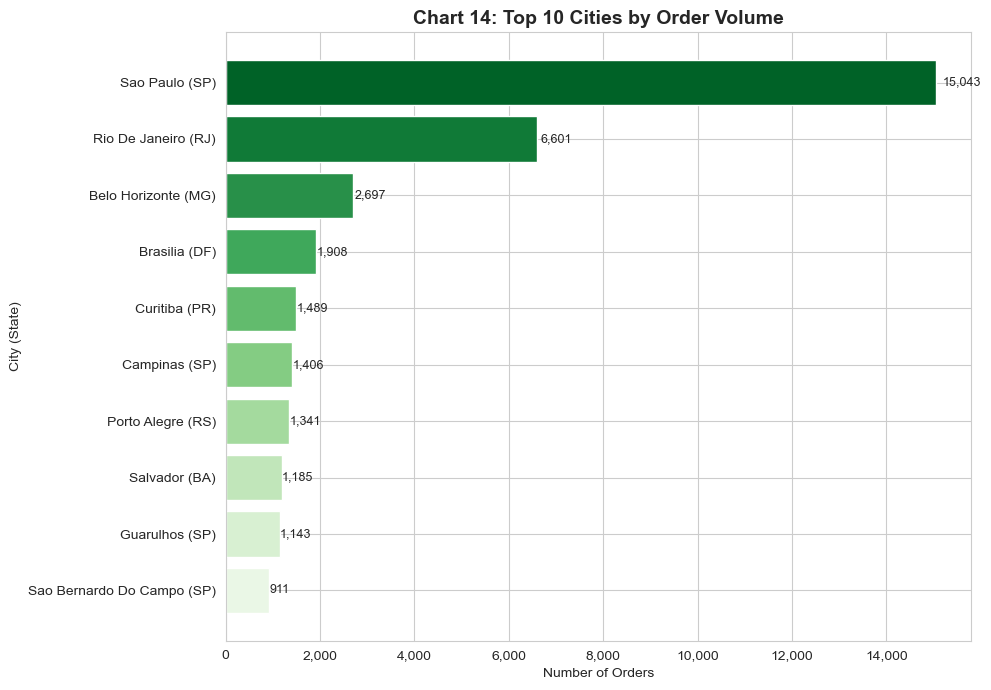

In [31]:
top10_cities = city_df.sort_values('order_count', ascending=False).head(10).copy()

# Gộp city + state để tránh trùng tên thành phố giữa các bang khác nhau
top10_cities['city_label'] = top10_cities['city'].str.title() + ' (' + top10_cities['state'] + ')'
top10_cities = top10_cities.sort_values('order_count')  # bar dài nhất nằm trên cùng

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette("Greens", len(top10_cities))  # single-hue ramp theo rank

bars = ax.barh(top10_cities['city_label'], top10_cities['order_count'], color=colors)

for bar, value in zip(bars, top10_cities['order_count']):
    ax.text(bar.get_width() + value*0.01, bar.get_y() + bar.get_height()/2,
            f"{value:,.0f}", va='center', fontsize=9)

ax.set_title('Chart 14: Top 10 Cities by Order Volume', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('City (State)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('top10_cities_order_volume.png', dpi=150)
plt.show()

### Top 10 state greatest by order

In [32]:
sns.set_style("whitegrid")

# --- Option A: Lấy từ SQL ---
query = """
SELECT
    c.customer_state AS state,
    SUM(i.price + i.freight_value) AS total_revenue,
    COUNT(DISTINCT o.order_id) AS order_count
FROM Cleaned_Orders o
JOIN Cleaned_Customers c ON o.customer_id = c.customer_id
JOIN Cleaned_Orders_Items i ON o.order_id = i.order_id
GROUP BY c.customer_state;
"""
state_df = pd.read_sql(query, engine)

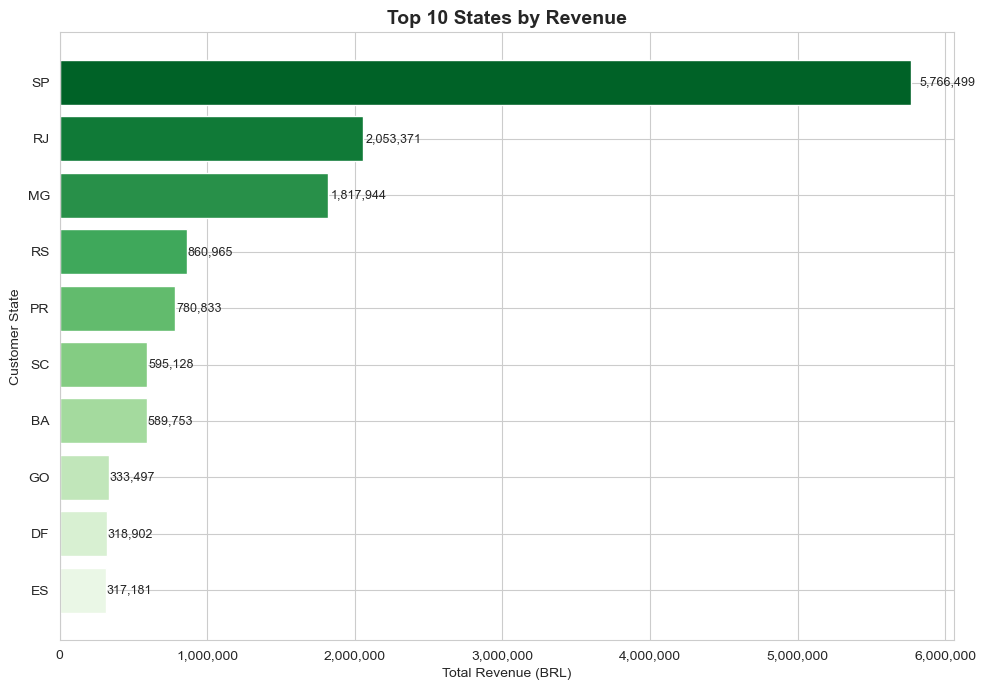

In [33]:
top_states = state_df.sort_values('total_revenue', ascending=False).head(10).copy()
top_states = top_states.sort_values('total_revenue')  # bar dài nhất nằm trên cùng

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette("Greens", len(top_states))  # single-hue ramp theo rank

bars = ax.barh(top_states['state'], top_states['total_revenue'], color=colors)

for bar, value in zip(bars, top_states['total_revenue']):
    ax.text(bar.get_width() + value*0.01, bar.get_y() + bar.get_height()/2,
            f"{value:,.0f}", va='center', fontsize=9)

ax.set_title('Top 10 States by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (BRL)')
ax.set_ylabel('Customer State')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('top_states_revenue.png', dpi=150)
plt.show()

In [34]:
total_revenue_all = state_df['total_revenue'].sum()
top_states['pct_of_total'] = (top_states['total_revenue'] / total_revenue_all * 100).round(2)
print(top_states[['state', 'total_revenue', 'pct_of_total']].sort_values('total_revenue', ascending=False))

   state  total_revenue  pct_of_total
5     SP     5766499.49         37.50
11    RJ     2053371.13         13.35
21    MG     1817943.67         11.82
9     RS      860965.07          5.60
16    PR      780832.57          5.08
17    SC      595127.78          3.87
19    BA      589753.13          3.84
0     GO      333497.17          2.17
7     DF      318901.58          2.07
15    ES      317181.05          2.06


### RFM customer

In [35]:
sns.set_style("whitegrid")

# rfm đã có cột R, F, M, monetary_total từ bước trước
rf_summary = (rfm.groupby(['R', 'F'])
              .agg(avg_monetary=('monetary_total', 'mean'),
                   customer_count=('monetary_total', 'count'))
              .reset_index())

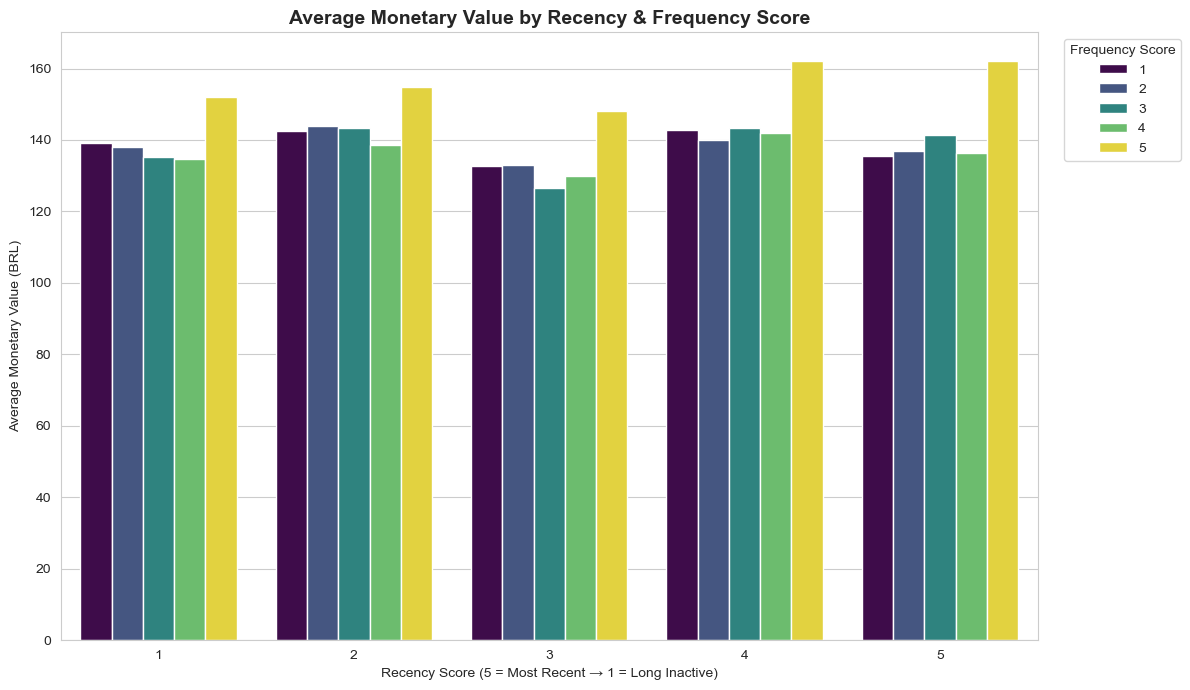

In [36]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=rf_summary,
    x='R', y='avg_monetary', hue='F',
    palette='viridis',
    ax=ax
)

ax.set_title('Average Monetary Value by Recency & Frequency Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Recency Score (5 = Most Recent → 1 = Long Inactive)')
ax.set_ylabel('Average Monetary Value (BRL)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='Frequency Score', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('rfm_grouped_bar.png', dpi=150)
plt.show()

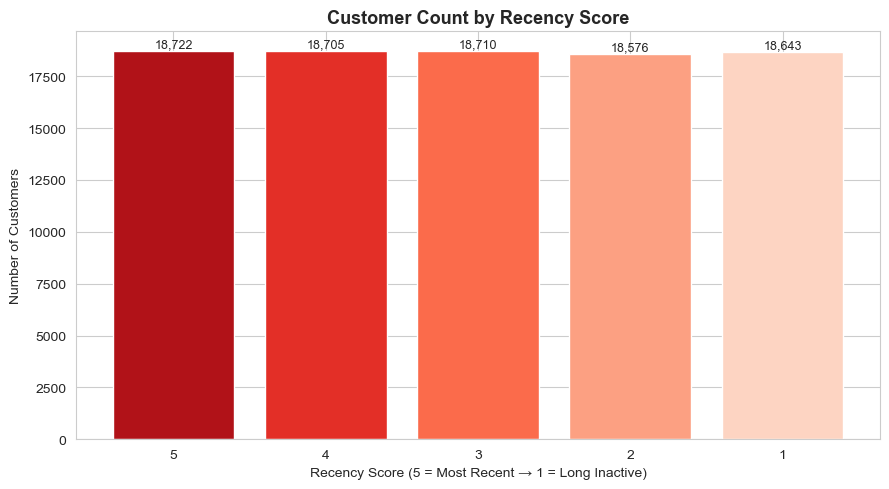

In [37]:
r_count = rfm['R'].value_counts().sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette("Reds_r", len(r_count))
bars = ax.bar(r_count.index.astype(str), r_count.values, color=colors)

for bar, value in zip(bars, r_count.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + value*0.01,
            f"{value:,}", ha='center', fontsize=9)

ax.set_title('Customer Count by Recency Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Recency Score (5 = Most Recent → 1 = Long Inactive)')
ax.set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig('rfm_recency_count_bar.png', dpi=150)
plt.show()

### Customer segment

In [38]:
sns.set_style("white")

# Nếu rfm đã có sẵn cột 'segment' từ notebook trước thì bỏ qua bước này
def assign_segment(row):
    r, f, m = row['R'], row['F'], row['M']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 4 and f <= 2:
        return 'New / Active'
    elif r <= 2 and m >= 4:
        return 'High-value Cooling Down'
    elif r <= 2 and m <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'At Risk'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

In [39]:
segment_counts = rfm['segment'].value_counts()
segment_pct = (segment_counts / segment_counts.sum() * 100).round(1)

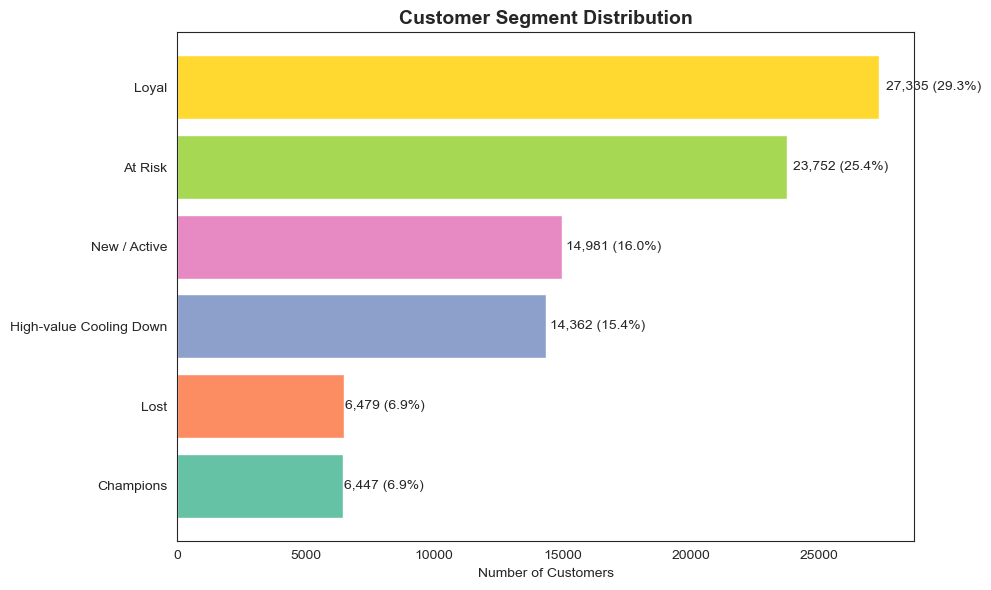

In [40]:
segment_sorted = segment_counts.sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = sns.color_palette("Set2", len(segment_sorted))
bars = ax.barh(segment_sorted.index, segment_sorted.values, color=colors_bar)

for bar, value, pct in zip(bars, segment_sorted.values, segment_pct.reindex(segment_sorted.index)):
    ax.text(bar.get_width() + value*0.01, bar.get_y() + bar.get_height()/2,
            f"{value:,} ({pct}%)", va='center', fontsize=10)

ax.set_title('Customer Segment Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Customers')
plt.tight_layout()
plt.savefig('chart7_segment_bar.png', dpi=150)
plt.show()

### phân loại payment credit

In [41]:
sns.set_style("white")

# --- Option A: Lấy từ SQL ---
query = """
SELECT
    payment_type,
    COUNT(*) AS payment_count
FROM Cleaned_Orders_Payments
GROUP BY payment_type
ORDER BY payment_count DESC;
"""
payment_df = pd.read_sql(query, engine)

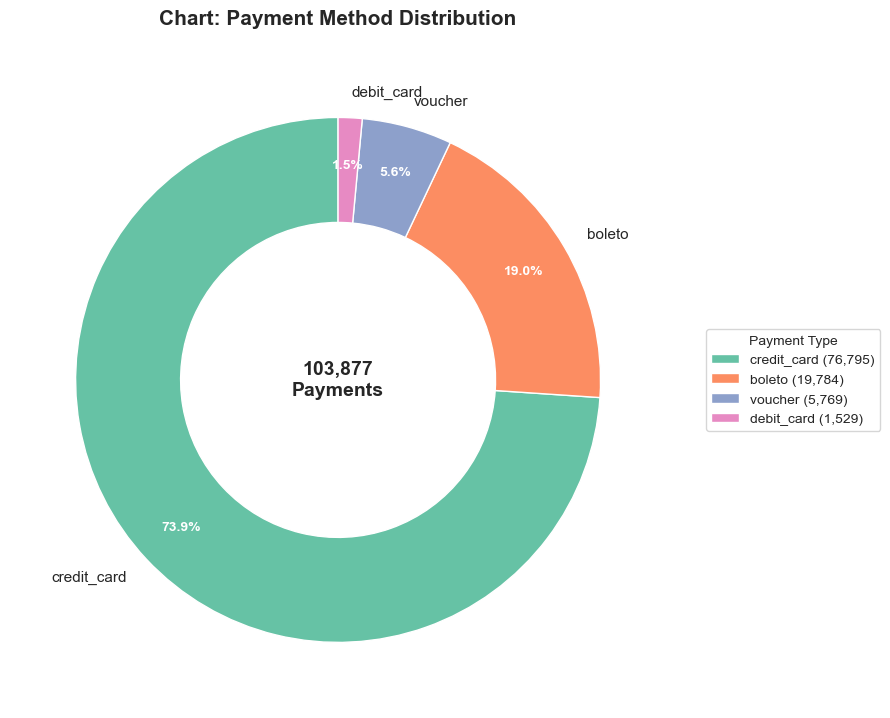

In [42]:
fig, ax = plt.subplots(figsize=(9, 9))

colors = sns.color_palette("Set2", len(payment_df))

wedges, texts, autotexts = ax.pie(
    payment_df['payment_count'],
    labels=payment_df['payment_type'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.82,
    wedgeprops=dict(width=0.4, edgecolor='white')
)

for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax.text(0, 0, f"{payment_df['payment_count'].sum():,}\nPayments",
        ha='center', va='center', fontsize=14, fontweight='bold')

ax.set_title('Chart: Payment Method Distribution', fontsize=15, fontweight='bold', pad=20)
ax.legend(wedges, [f"{pt} ({cnt:,})" for pt, cnt in zip(payment_df['payment_type'], payment_df['payment_count'])],
          title="Payment Type", loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=10)

plt.tight_layout()
plt.savefig('chart15_payment_method_donut.png', dpi=150, bbox_inches='tight')
plt.show()

### time average for delivery

In [43]:
sns.set_style("whitegrid")

# --- Option A: Lấy từ SQL (khớp với Query 2 trong báo cáo) ---
query = """
SELECT
    c.customer_state AS state,
    ROUND(AVG(CAST(DATEDIFF(day, o.order_purchase_timestamp,
        o.order_delivered_customer_date) AS FLOAT)), 2) AS avg_delivery_days,
    MIN(DATEDIFF(day, o.order_purchase_timestamp,
        o.order_delivered_customer_date)) AS min_delivery_days,
    MAX(DATEDIFF(day, o.order_purchase_timestamp,
        o.order_delivered_customer_date)) AS max_delivery_days,
    COUNT(DISTINCT o.order_id) AS total_orders
FROM Cleaned_Orders o
JOIN Cleaned_Customers c ON o.customer_id = c.customer_id
WHERE DATEDIFF(day, o.order_purchase_timestamp,
      o.order_delivered_customer_date) BETWEEN 0 AND 60
GROUP BY c.customer_state;
"""
delivery_df = pd.read_sql(query, engine)


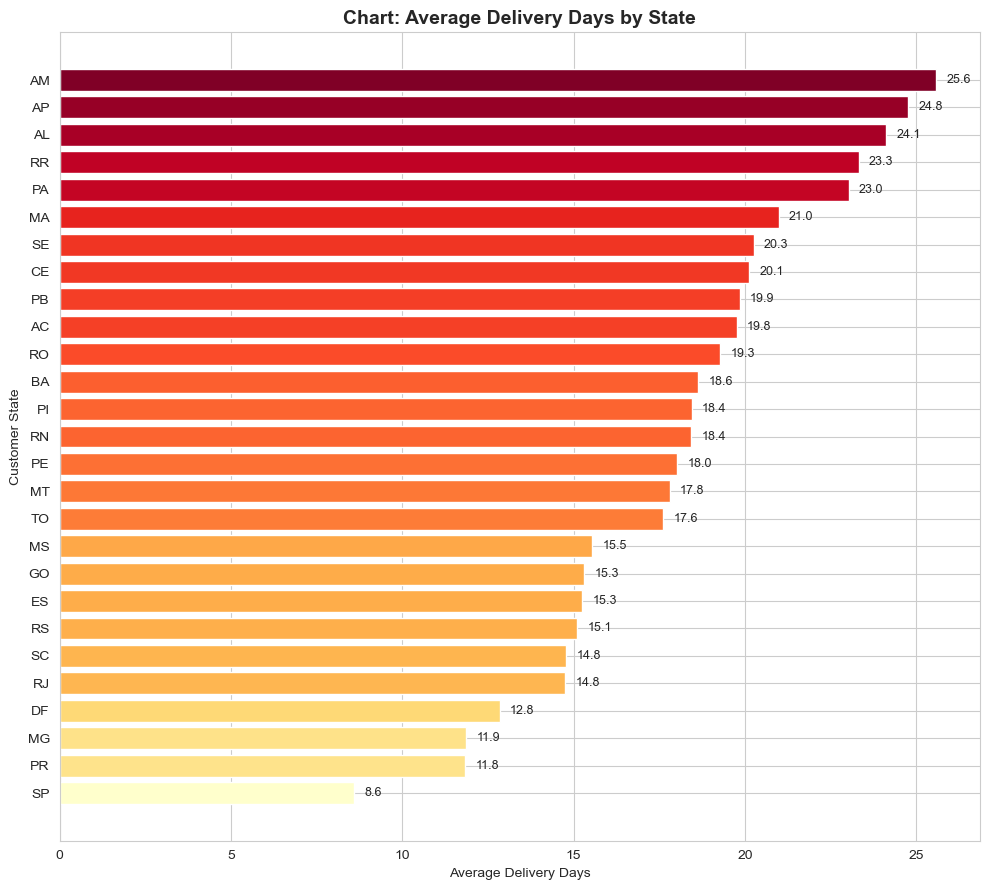

In [44]:
delivery_sorted = delivery_df.sort_values('avg_delivery_days', ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))

# Color gradient theo severity: càng chậm càng đỏ đậm
norm = plt.Normalize(delivery_sorted['avg_delivery_days'].min(), delivery_sorted['avg_delivery_days'].max())
colors = plt.cm.YlOrRd(norm(delivery_sorted['avg_delivery_days']))

bars = ax.barh(delivery_sorted['state'], delivery_sorted['avg_delivery_days'], color=colors)

for bar, value in zip(bars, delivery_sorted['avg_delivery_days']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{value:.1f}", va='center', fontsize=9)

ax.set_title('Chart: Average Delivery Days by State', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Delivery Days')
ax.set_ylabel('Customer State')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))

plt.tight_layout()
plt.savefig('chart8_avg_delivery_by_state.png', dpi=150)
plt.show()

In [45]:
print(delivery_df.sort_values('avg_delivery_days', ascending=False)[
    ['state', 'avg_delivery_days', 'min_delivery_days', 'max_delivery_days', 'total_orders']
].head(10))

   state  avg_delivery_days  min_delivery_days  max_delivery_days  \
18    AM              25.58                  4                 57   
24    AP              24.76                  5                 45   
13    AL              24.12                  4                 60   
23    RR              23.32                  6                 54   
8     PA              23.03                  5                 60   
1     MA              20.98                  3                 58   
10    SE              20.26                  6                 56   
2     CE              20.12                  3                 58   
3     PB              19.85                  6                 54   
12    AC              19.76                  7                 43   

    total_orders  
18           144  
24            66  
13           393  
23            38  
8            933  
1            709  
10           331  
2           1253  
3            510  
12            78  


### reviewed by time delivery

In [46]:
sns.set_style("whitegrid")

# --- Option A: Lấy từ SQL ---
query = """
SELECT
    r.review_score,
    DATEDIFF(day, o.order_purchase_timestamp, o.order_delivered_customer_date) AS delivery_days
FROM Cleaned_Orders o
JOIN order_reviews r ON o.order_id = r.order_id
WHERE DATEDIFF(day, o.order_purchase_timestamp, o.order_delivered_customer_date) BETWEEN 0 AND 60;
"""
review_delivery_df = pd.read_sql(query, engine)

In [47]:
summary = (review_delivery_df.groupby('review_score')['delivery_days']
           .agg(['mean', 'std', 'count'])
           .reset_index())
summary['se'] = summary['std'] / summary['count']**0.5  # standard error

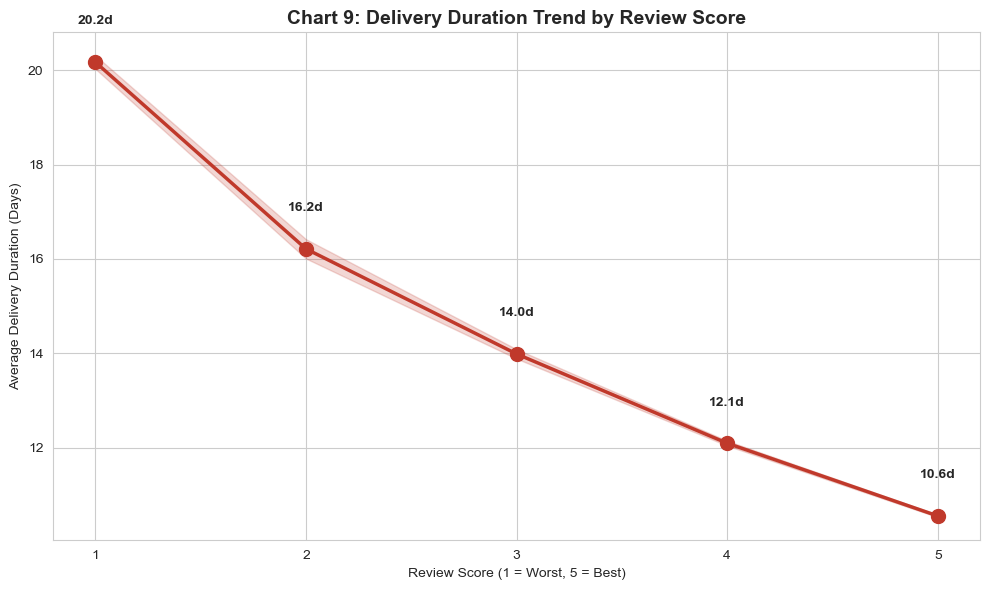

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(summary['review_score'], summary['mean'], marker='o', linewidth=2.5,
        markersize=10, color='#C0392B')
ax.fill_between(summary['review_score'],
                 summary['mean'] - summary['se'],
                 summary['mean'] + summary['se'],
                 alpha=0.2, color='#C0392B')

for x, y in zip(summary['review_score'], summary['mean']):
    ax.text(x, y + 0.8, f"{y:.1f}d", ha='center', fontsize=10, fontweight='bold')

ax.set_title('Chart 9: Delivery Duration Trend by Review Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Review Score (1 = Worst, 5 = Best)')
ax.set_ylabel('Average Delivery Duration (Days)')
ax.set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig('chart9_delivery_by_review_line.png', dpi=150)
plt.show()

In [49]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# --- Option A: Lấy từ SQL (join customers với geolocation) ---
query = """
SELECT
    g.geolocation_lat AS lat,
    g.geolocation_lng AS lng,
    COUNT(DISTINCT c.customer_id) AS customer_count
FROM Cleaned_Customers c
JOIN geolocation g
    ON c.customer_zip_code_prefix = g.geolocation_zip_code_prefix
GROUP BY g.geolocation_lat, g.geolocation_lng;
"""
geo_df = pd.read_sql(query, engine)


# Lọc bỏ toạ độ lỗi/ngoài lãnh thổ Brazil (bounding box thực tế của Brazil)
geo_df = geo_df[
    (geo_df['lat'].between(-33.75, 5.27)) &
    (geo_df['lng'].between(-73.99, -34.79))
]

In [66]:
# Tâm bản đồ đặt tại trung tâm địa lý gần đúng của Brazil
brazil_center = [-14.2350, -51.9253]

m = folium.Map(location=brazil_center, zoom_start=4, tiles='CartoDB positron')

# Chuẩn bị dữ liệu cho HeatMap: [lat, lng, weight]
heat_data = geo_df[['lat', 'lng', 'customer_count']].values.tolist()

HeatMap(
    heat_data,
    radius=8,
    blur=6,
    max_zoom=6,
    min_opacity=0.3
).add_to(m)

# Thêm attribution/tiêu đề (Folium không có title mặc định, dùng HTML overlay)
title_html = '''
    <h3 align="center" style="font-size:18px"><b>Chart: Folium Customer Geolocation Heatmap</b></h3>
'''
m.get_root().html.add_child(folium.Element(title_html))

# Lưu ra file HTML để nhúng vào dashboard hoặc mở trực tiếp trên trình duyệt
m.save('chart13_customer_geolocation_heatmap.png')
m

In [68]:
# Cài đặt (chạy 1 lần trong terminal/notebook)
# pip install selenium --break-system-packages

import time
from selenium import webdriver
from selenium.webdriver.chrome.options import Options

# Cấu hình Chrome chạy ẩn (headless)
options = Options()
options.add_argument('--headless')
options.add_argument('--window-size=1200,800')
options.add_argument('--no-sandbox')

driver = webdriver.Chrome(options=options)

# Mở file HTML đã lưu từ bước trước
import os
html_path = os.path.abspath('chart13_customer_geolocation_heatmap.html')
driver.get(f'file://{html_path}')

time.sleep(3)  # đợi bản đồ load xong (tiles + heatmap render)

driver.save_screenshot('chart13_static.png')
driver.quit()

print("Đã lưu ảnh tĩnh: chart13_static.png")

Đã lưu ảnh tĩnh: chart13_static.png


## Models

In [50]:
import numpy as np

rfm_model = rfm_df.copy()

# Log-transform để giảm lệch (thêm 1 để tránh log(0))
rfm_model['recency_log'] = rfm_model['recency_days']
rfm_model['frequency_log'] = np.log1p(rfm_model['purchase_frequency'])
rfm_model['monetary_log']  = np.log1p(rfm_model['monetary_total'])

In [51]:
rfm_model = rfm_df.copy()

# Skewness trước Log Transform
skew_before = rfm_model[['recency_days', 'purchase_frequency', 'monetary_total']].skew()

# Log Transform
rfm_model['recency_log'] = rfm_model['recency_days']
rfm_model['frequency_log'] = np.log1p(rfm_model['purchase_frequency'])
rfm_model['monetary_log'] = np.log1p(rfm_model['monetary_total'])

# Skewness sau Log Transform
skew_after = rfm_model[['recency_log', 'frequency_log', 'monetary_log']].skew()

# So sánh
comparison = pd.DataFrame({
    'Before Log': skew_before.values,
    'After Log': skew_after.values
}, index=['Recency', 'Frequency', 'Monetary'])

print(comparison.round(3))

           Before Log  After Log
Recency         0.448      0.448
Frequency      11.095      6.522
Monetary        9.269      0.274


In [52]:
from sklearn.preprocessing import StandardScaler

features = ['recency_days','frequency_log', 'monetary_log']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_model[features])

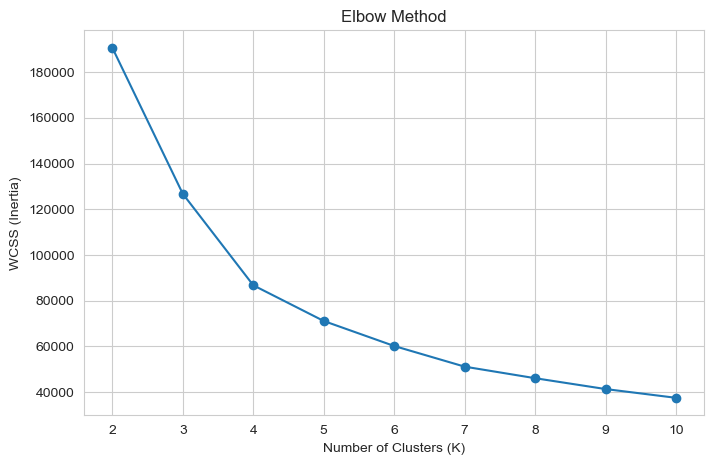

In [53]:
inertia = []
K = range(2,11)

for k in K:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [54]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_model['cluster'] = kmeans_final.fit_predict(X_scaled)

In [55]:
centroids = rfm_model.groupby('cluster')[['recency_days','purchase_frequency','monetary_total']].mean()


In [56]:
print("Silhouette:", silhouette_score(X_scaled, rfm_model['cluster']))
print("Davies-Bouldin:", davies_bouldin_score(X_scaled, rfm_model['cluster']))

Silhouette: 0.3659408072802986
Davies-Bouldin: 0.78209077093508


In [57]:
# Gán nhãn segment dựa trên đặc điểm thực tế của từng cluster
segment_map = {
    0: 'Cooling down (high spend)',   # recency cao, monetary khá cao, mua 1 lần
    1: 'Champions / Loyal',           # frequency & monetary cao nhất
    2: 'At risk / Low-value',         # recency cao nhất, monetary thấp nhất
    3: 'New customers'                # recency thấp nhất (mới mua gần đây)
}

centroids['segment_label'] = centroids.index.map(segment_map)
rfm_model['segment_label'] = rfm_model['cluster'].map(segment_map)

print(centroids)
print(rfm_model['segment_label'].value_counts())

         recency_days  purchase_frequency  monetary_total  \
cluster                                                     
0          220.294538            2.113888      260.053106   
1          161.298410            1.000000      250.392999   
2          426.430135            1.000000      109.945591   
3          154.777835            1.000000       44.398772   

                     segment_label  
cluster                             
0        Cooling down (high spend)  
1                Champions / Loyal  
2              At risk / Low-value  
3                    New customers  
segment_label
Champions / Loyal            32395
New customers                31022
At risk / Low-value          27138
Cooling down (high spend)     2801
Name: count, dtype: int64


In [58]:
segment_map = {
    0: 'Cooling down (high spend)',
    1: 'Champions / Loyal',
    2: 'At risk / Low-value',
    3: 'New customers'
}

centroids['segment_label'] = centroids.index.map(segment_map)
rfm_model['segment_label'] = rfm_model['cluster'].map(segment_map)   # <-- dòng này phải chạy lại

print(rfm_model['segment_label'].unique())   # kiểm tra xem có đúng 4 nhãn mới không

['Champions / Loyal' 'New customers' 'At risk / Low-value'
 'Cooling down (high spend)']


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
palette_colors = sns.color_palette("Set2", n_colors=rfm_model['segment_label'].nunique())
color_map = dict(zip(rfm_model['segment_label'].unique(), palette_colors))

# --- 1. Bar chart: số lượng khách hàng theo segment ---
plt.figure(figsize=(8,5))
order = rfm_model['segment_label'].value_counts().index
sns.countplot(data=rfm_model, x='segment_label', order=order,
              palette=[color_map[s] for s in order])
plt.title('Số lượng khách hàng theo Segment')
plt.xlabel('')
plt.ylabel('Số khách hàng')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('segment_count.png', dpi=150)
plt.show()


NameError: name 'rfm_model' is not defined

In [ ]:
# --- 2. Bar chart: trung bình R-F-M theo segment ---
fig, axes = plt.subplots(1, 3, figsize=(16,5))
metrics = ['recency_days', 'purchase_frequency', 'monetary_total']
titles = ['Recency trung bình (ngày)', 'Frequency trung bình', 'Monetary trung bình']

for ax, metric, title in zip(axes, metrics, titles):
    data = rfm_model.groupby('segment_label')[metric].mean().reindex(order)
    ax.bar(data.index, data.values, color=[color_map[s] for s in data.index])
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('rfm_by_segment.png', dpi=150)
plt.show()


In [ ]:


# --- 3. Scatter plot: Recency vs Monetary, màu theo segment ---
plt.figure(figsize=(8,6))
for seg in order:
    subset = rfm_model[rfm_model['segment_label'] == seg]
    plt.scatter(subset['recency_days'], subset['monetary_total'],
                label=seg, alpha=0.5, s=20, color=color_map[seg])
plt.xlabel('Recency (ngày)')
plt.ylabel('Monetary (R$)')
plt.title('Phân bố khách hàng theo Recency & Monetary')
plt.legend()
plt.tight_layout()
plt.savefig('scatter_recency_monetary.png', dpi=150)
plt.show()



In [ ]:
# --- 4. Boxplot: phân phối monetary theo segment (kiểm tra outlier) ---
plt.figure(figsize=(8,5))
sns.boxplot(data=rfm_model, x='segment_label', y='monetary_total',
            order=order, palette=[color_map[s] for s in order])
plt.yscale('log')  # vì monetary thường lệch phải mạnh
plt.title('Phân phối Monetary theo Segment (log scale)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('boxplot_monetary.png', dpi=150)
plt.show()


In [ ]:

# --- 5. Pie chart: tỷ lệ % segment ---
plt.figure(figsize=(7,7))
sizes = rfm_model['segment_label'].value_counts().reindex(order)
plt.pie(sizes, labels=sizes.index, autopct='%1.1f%%',
        colors=[color_map[s] for s in order], startangle=90)
plt.title('Tỷ lệ khách hàng theo Segment')
plt.tight_layout()
plt.savefig('pie_segment.png', dpi=150)
plt.show()